In [45]:
import json
import os
from io import BytesIO
from pathlib import Path
from pprint import pprint

import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnnotationBbox, OffsetImage
from matplotlib.patches import Circle
from mplsoccer import Pitch, VerticalPitch
import numpy as np
from PIL import Image, ImageDraw
import polars as pl
import requests
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
import statsmodels.formula.api as smf

## Import events
Import the event .json files into a Polars data frame

In [46]:
# WSL women's data
data_dir_path = 'twelve_course_data/368/2025/'

In [47]:
dfs = []
events_dir_path = Path(data_dir_path + 'events/')
json_files = list(events_dir_path.glob('*.json'))

for file in json_files:
    df = pl.read_json(file)
    
    # Explode event attributes into columns
    if 'events' in df.columns:
        events_df = df.select('events').explode('events').unnest('events')
        dfs.append(events_df)

events_pl = pl.concat(dfs)

## Import match data

In [48]:
matches_pl = pl.read_parquet(data_dir_path + 'matches.parquet')
matches_pl = matches_pl.with_columns(
  pl.col('date').str.slice(0, 10).alias('matchDate')
)

In [49]:
# Join events with matches to get the match date
match_dates_pl = matches_pl.select(
  pl.col('match_id').alias('matchId'),
  pl.col('matchDate')
)

events_pl = events_pl.join(
  match_dates_pl, on='matchId', how='left'
).with_columns(
  (pl.col('matchDate') + ' ' + pl.col('matchTimestamp'))
  .str.to_datetime(format='%Y-%m-%d %H:%M:%S%.3f')
  .alias('matchTs'),
  # (pl.col('type').struct.field('primary') == 'shot').alias('isShotEvent'),
).drop(['videoTimestamp', 'minute', 'second', 'matchDate', 'matchTimestamp'])

# That is all we need the match data for, so bye-bye
del matches_pl

## Import parquet files

In [50]:
# Minutes
minutes_dir_path = Path(data_dir_path + 'minutes/')
pq_files = list(minutes_dir_path.glob('*.parquet'))
dfs = []
for pf in pq_files:
    df = pl.read_parquet(pf)
    dfs.append(df)
minutes_pl = pl.concat(dfs)

# Players
players_pl = pl.read_parquet(data_dir_path + 'players.parquet')

# Teams
teams_pl = pl.read_parquet(data_dir_path + 'teams.parquet')

# Some lookup tables for data that should be included in the data files but, sadly, is not
wsl_abbrvs = {
    'Arsenal': 'ARS',
    'Aston Villa': 'AVL',
    'Birmingham City': 'BIR',
    'Brighton & Hove Albion': 'BHA',
    'Bristol City': 'BCW',
    'Charlton Athletic': 'CHA',
    'Chelsea': 'CHE',
    'Crystal Palace': 'CRY',
    'Everton': 'EVE',
    'Leicester City WFC': 'LEI',
    'Liverpool': 'LIV',
    'London City Lionesses': 'LCL',
    'Manchester City': 'MCI',
    'Manchester United': 'MUN',
    'Tottenham Hotspur': 'TOT',
    'West Ham United': 'WHU'
}

# Gemini generated this dictionary for me
wsl_colours = {
    'Arsenal': ['#EF0107', '#FFFFFF'],
    'Aston Villa': ['#670E36', '#95BFE5'],
    'Birmingham City': ['#002147', '#FFFFFF'],
    'Brighton & Hove Albion': ['#0057B8', '#FFFFFF'],
    'Bristol City': ['#E41F3C', '#FFFFFF'], 
    'Charlton Athletic': ['#E03A3E', '#FFFFFF'],
    'Chelsea': ['#034694', '#FFFFFF'],
    'Crystal Palace': ['#1B458F', '#A7A5A6'],
    'Everton': ['#003399', '#FFFFFF'],
    'Leicester City WFC': ['#003062', '#FFFFFF'],
    'Liverpool': ['#C8102E', '#FFFFFF'],
    'London City Lionesses': ['#002D62', '#FFD200'],
    'Manchester City': ['#6CABDD', '#FFFFFF'],
    'Manchester United': ['#DA291C', '#FFFFFF', '#000000'],
    'Tottenham Hotspur': ['#132257', '#A1A1A4'],
    'West Ham United': ['#7A263A', '#1BB1E7']
}

teams_abbrvs = [wsl_abbrvs[t] for t in teams_pl['name'].to_list()]
teams_pl = teams_pl.with_columns(
  pl.Series('team_abbrv', teams_abbrvs)
)

## Transform data
Use `matchId` and `possessionId` combinations to track possession chains

In [51]:
possession_events_pl = events_pl.filter(
  # Remove penalty shots
  ~pl.col('type').struct.field('secondary').list.contains('penalty_conceded_goal'),
  ~pl.col('type').struct.field('secondary').list.contains('penalty_goal'),
  ~pl.col('type').struct.field('secondary').list.contains('penalty_save'),
).with_columns(
  # Promote the team name and possession id struct fields to top level columns for easier access
  pl.col('team').struct.field('name').alias('teamName'),
  pl.col('possession').struct.field('id').alias('possessionId'),
).with_columns(
  # Create a column to set all rows of a possession chain to true if the possession ends in a shot
  (pl.col('type').struct.field('primary') == 'shot').any().over(['matchId', 'possessionId']).alias('isShotEvent'),
  # Create a column to set all rows of a possession chain to true if the possession ends in a goal
  (pl.col('shot').struct.field('isGoal') == True).any().over(['matchId', 'possessionId']).alias('isGoalEvent'),
).with_columns(
  # Get the team name for the possession by taking the first teamName in each possession group
  pl.col('teamName').first().over('matchId', 'possessionId').alias('possessionTeamName')
).with_columns(
  # Create a temp column that tracks when the team in the event is different from the possession team
  (pl.col('teamName') != pl.col('possessionTeamName')).alias('temp_notPossessionTeam')
).with_columns(
  # Create a temp column that identifies when there are consecutive events where the team is not the possession team
  # (i.e. opponent has 2 or more consecutive events in the same possession)
  (pl.col('temp_notPossessionTeam') &
   pl.col('temp_notPossessionTeam').shift(-1).over('matchId', 'possessionId')).alias('temp_opponentConsecutivePossession')
).with_columns(
  # Create a temp column that identifies possessions that have any opponent consecutive possession events
  pl.col('temp_opponentConsecutivePossession').any().over(['matchId', 'possessionId']).alias('temp_removeEvent')
).filter(
  # Remove all possessions that have any opponent consecutive possession events
  ~pl.col('temp_removeEvent')
).drop(['temp_notPossessionTeam', 'temp_opponentConsecutivePossession', 'temp_removeEvent'])

print('All events:', events_pl.shape)
print('Possession events:', possession_events_pl.shape)



All events: (223414, 17)
Possession events: (161426, 22)


Remove all events that are not within 15 seconds of the shot event

In [52]:
# Get matches and possessions that have shot events
shots_per_possession = possession_events_pl.filter(
  pl.col('isShotEvent') == True
).select(
  ['matchId', 'possessionId', 'matchTs']
).group_by(
  ['matchId', 'possessionId']
).agg(
  pl.col('matchTs').max().alias('temp_ShotTs')
)

# Join back to events and filter
possession_events_pl = possession_events_pl.join(
  shots_per_possession,
  on=['matchId', 'possessionId'],
  how='left'
).filter(
  pl.col('temp_ShotTs').is_null()
  | (pl.col('matchTs') >= (pl.col('temp_ShotTs') - pl.duration(seconds=15)))
).drop('temp_ShotTs')

print(possession_events_pl.shape)

(155263, 22)


## Analyze coordinates
All coordinate values are between 0 and 100, and all shot events are oriented left to right, so it looks like we are using Wyscout data

In [53]:
with pl.Config(tbl_rows=-1):
  print(
    possession_events_pl.select(
      [
        pl.col('location').struct.field('x').min().alias('x_min'),
        pl.col('location').struct.field('x').max().alias('x_max'),
        pl.col('location').struct.field('y').min().alias('y_min'),
        pl.col('location').struct.field('y').max().alias('y_max'),
      ]
    )
  )

shape: (1, 4)
┌───────┬───────┬───────┬───────┐
│ x_min ┆ x_max ┆ y_min ┆ y_max │
│ ---   ┆ ---   ┆ ---   ┆ ---   │
│ i64   ┆ i64   ┆ i64   ┆ i64   │
╞═══════╪═══════╪═══════╪═══════╡
│ 0     ┆ 100   ┆ 0     ┆ 100   │
└───────┴───────┴───────┴───────┘


Plot all shot and goal data on a Wyscout pitch to confirm

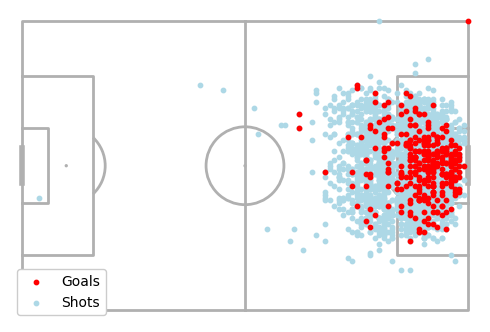

In [54]:
sg_pitch = Pitch(pitch_type='wyscout')
fig, ax = sg_pitch.draw(figsize=(5, 3.5))

goal_xy_pl = possession_events_pl.filter(
  pl.col('shot').struct.field('isGoal') == True

).select(
  pl.col('location').struct.field('x').alias('x'),
  pl.col('location').struct.field('y').alias('y'),
)

sg_pitch.scatter(
  goal_xy_pl['x'],
  goal_xy_pl['y'],
  ax=ax,
  c='red',
  s=10,
  zorder=2,
  label='Goals'
)

shot_xy_pl = possession_events_pl.filter(
  pl.col('type').struct.field('primary') == 'shot'
).select(
  pl.col('location').struct.field('x').alias('x'),
  pl.col('location').struct.field('y').alias('y'),
)

sg_pitch.scatter(
  shot_xy_pl['x'],
  shot_xy_pl['y'],
  ax=ax,
  c='lightblue',
  s=10,
  label='Shots',
)

ax.legend(loc='lower left', fontsize=10, framealpha=1.0)

## Convert coordinates
Convert all event start and end coordinates to meters

In [55]:
PITCH_X_M = 105  # meters
PITCH_Y_M = 68  # meters
X_CONV_TO_M = PITCH_X_M/100
Y_CONV_TO_M = PITCH_Y_M/100
GOAL_WIDTH_M = 7.32
GOAL_Y_TOP = (PITCH_Y_M/2) - (GOAL_WIDTH_M/2)
GOAL_Y_BOT = (PITCH_Y_M/2) + (GOAL_WIDTH_M/2)

xfm_events_pl = possession_events_pl.with_columns(
  (pl.col('location').struct.field('x') * X_CONV_TO_M).alias('startXMeters'),
  (pl.col('location').struct.field('y') * Y_CONV_TO_M).alias('startYMeters'),
  pl.when(
      pl.col('pass').is_not_null()
  ).then(
      pl.struct(
          endXMeters=(pl.col('pass').struct.field('endLocation').struct.field('x') * X_CONV_TO_M),
          endYMeters=(pl.col('pass').struct.field('endLocation').struct.field('y') * Y_CONV_TO_M),
      )
  ).when(
      pl.col('carry').is_not_null()
  ).then(
      pl.struct(
          endXMeters=(pl.col('carry').struct.field('endLocation').struct.field('x') * X_CONV_TO_M),
          endYMeters=(pl.col('carry').struct.field('endLocation').struct.field('y') * Y_CONV_TO_M),
      )
  ).when(
      pl.col('shot').is_not_null()
  ).then(
      # Shots do not have any end location so just set it to center of goal
      pl.struct(
          endXMeters=pl.lit(PITCH_X_M),
          endYMeters=pl.lit(PITCH_Y_M/2),
      )
  ).when(
      pl.col('possession').is_null()
  ).then(
      # When possession is null, the only coordinates available are the event location
      pl.struct(
          endXMeters=(pl.col('location').struct.field('x') * X_CONV_TO_M),
          endYMeters=(pl.col('location').struct.field('y') * Y_CONV_TO_M),
      )
  ).otherwise(
      pl.struct(
          endXMeters=(pl.col('possession').struct.field('endLocation').struct.field('x') * X_CONV_TO_M),
          endYMeters=(pl.col('possession').struct.field('endLocation').struct.field('y') * Y_CONV_TO_M),
      )
  ).struct.unnest()  # Unnest endXMeters and endYMeters into columns
).with_columns(
    # Calculate the distance of each event
    (((pl.col('endXMeters') - pl.col('startXMeters')).pow(2) + 
      (pl.col('endYMeters') - pl.col('startYMeters')).pow(2)).sqrt()).alias('distanceMeters')
)

Calculate shot angles

In [56]:
# Use inverse cosine to get the angle to goal with the shot location as the shared endpoint
sx = xfm_events_pl['startXMeters'].to_numpy()
sy = xfm_events_pl['startYMeters'].to_numpy()

v0 = np.vstack((PITCH_X_M - sx, GOAL_Y_TOP - sy))
v1 = np.vstack((PITCH_X_M - sx, GOAL_Y_BOT - sy))

# dot = np.einsum('ij,ij->j', v0, v1)
dot = np.sum(v0 * v1, axis=0)
norm0 = np.linalg.norm(v0, axis=0)
norm1 = np.linalg.norm(v1, axis=0)
denom = norm0 * norm1

# safe cosine, handle zero-length vectors
cosang = np.zeros_like(dot, dtype=float)
valid = denom > 0
cosang[valid] = dot[valid] / denom[valid]
cosang = np.clip(cosang, -1.0, 1.0)

angle_rad = np.arccos(cosang)
angle_deg = np.degrees(angle_rad)

# set NaN for invalid rows (where denom == 0)
angle_deg[~valid] = np.nan

xfm_events_pl = xfm_events_pl.with_columns(
  pl.Series('angleToGoalRad', angle_rad),
  pl.Series('angleToGoalDeg', angle_deg),
)

Plot some shot angles to verify that they look correct

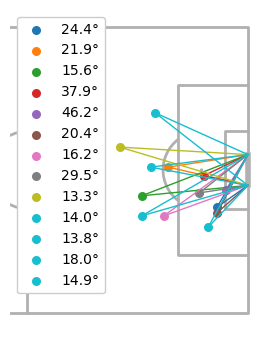

In [57]:
shot_events = xfm_events_pl.filter(
  pl.col('type').struct.field('primary') == 'shot',
  pl.col('matchId') == 5767664,
  pl.col('team').struct.field('id') == 1965,
).select(
  ['startXMeters', 'startYMeters', 'angleToGoalDeg']
)

angles_pitch = Pitch(half=True, pitch_type='custom', pitch_length=PITCH_X_M, pitch_width=PITCH_Y_M)
fig, ax = angles_pitch.draw(figsize=(5, 3.5))

color_counter = 0
for shot_event in shot_events.iter_rows(named=True):
  shot_x = shot_event['startXMeters']
  shot_y = shot_event['startYMeters']
  ang_deg = shot_event['angleToGoalDeg']

  goal_y0 = 34 - GOAL_WIDTH_M / 2
  goal_y1 = 34 + GOAL_WIDTH_M / 2
  color = plt.cm.tab10(color_counter)
  ax.scatter([shot_x], [shot_y], c=[color], s=30, zorder=1, label=f'{ang_deg:.1f}°')
  ax.plot([shot_x, PITCH_X_M], [shot_y, GOAL_Y_TOP], c=color, linewidth=1, zorder=2)
  ax.plot([shot_x, PITCH_X_M], [shot_y, GOAL_Y_BOT], c=color, linewidth=1, zorder=2)
  ax.legend(loc='upper left', framealpha=1.0)
  color_counter += 1

Check the mean and median angles to make sure they are reasonable

In [58]:
xfm_events_pl.select(
  (pl.col('angleToGoalDeg').drop_nans().mean()).alias('avg'),
  (pl.col('angleToGoalDeg').drop_nans().median()).alias('median'),
)

avg,median
f64,f64
7.390954,6.005738


## xG Model
Train a logistic regression model to calculate expected goals

In [59]:
xg_model = smf.glm(
  formula='isGoalEvent ~ distanceMeters + angleToGoalRad',
  data=xfm_events_pl.select(['isGoalEvent', 'distanceMeters', 'angleToGoalRad']).to_pandas(),
  family=sm.families.Binomial()
).fit()
print(xg_model.summary())

                              Generalized Linear Model Regression Results                              
Dep. Variable:     ['isGoalEvent[False]', 'isGoalEvent[True]']   No. Observations:               155138
Model:                                                     GLM   Df Residuals:                   155135
Model Family:                                         Binomial   Df Model:                            2
Link Function:                                           Logit   Scale:                          1.0000
Method:                                                   IRLS   Log-Likelihood:                -9445.1
Date:                                         Tue, 23 Jun 2026   Deviance:                       18890.
Time:                                                 10:26:39   Pearson chi2:                 1.38e+05
No. Iterations:                                              8   Pseudo R-squ. (CS):           0.005223
Covariance Type:                                     nonrobust  

Calculate xG for all shot events

In [60]:
intercept, dist_coef, ang_coef = xg_model.params.to_list()

xG = 1 / (1 + np.exp(intercept + dist_coef * xfm_events_pl['distanceMeters'] + ang_coef * xfm_events_pl['angleToGoalRad']))
xfm_events_pl = xfm_events_pl.with_columns(
  pl.Series('xG', xG)
)

## Action-based xT
Create the models for calculating xT

In [61]:
# Feature and target column names for both the logistic and linear regression models
feature_cols = ['startXMeters', 'startYMeters', 'endXMeters', 'endYMeters']
shot_target_col = 'isShotEvent'
xg_target_col = 'xG'

# First drop rows with null values in the feature and target columns before training
abxt_pl = xfm_events_pl.drop_nulls(
  subset=feature_cols + [shot_target_col, xg_target_col]
)

## Shot probability
Use a logistic regression model to predict the probability an event leads to a shot outcome

In [62]:
shot_pred_features_pd = abxt_pl.select(
    feature_cols + [shot_target_col]
).to_pandas()

X_s = shot_pred_features_pd[feature_cols].values
y_s = shot_pred_features_pd[shot_target_col].astype(int).values

X_s_train, X_s_test, y_s_train, y_s_test = train_test_split(
  X_s, y_s,
  test_size=0.2,
  random_state=1001,
)

is_shot_log_model = LogisticRegression(max_iter=1000)
is_shot_log_model.fit(X_s_train, y_s_train)

shot_preds = is_shot_log_model.predict(X_s_test)
acc = accuracy_score(y_s_test, shot_preds)
print(f'Model accuracy: {acc:.4f}')

Model accuracy: 0.9023


## Predicted xG
Use a linear regression model to predict xG for every event

In [63]:
xg_pred_features_pd = abxt_pl.select(
  feature_cols + [xg_target_col]
).to_pandas()

X_g = xg_pred_features_pd[feature_cols].values
y_g = xg_pred_features_pd[xg_target_col].values

X_g_train, X_g_test, y_g_train, y_g_test = train_test_split(
  X_g, y_g,
  test_size=0.2,
  random_state=1001,
)

xg_pred_lin_model = LinearRegression()
xg_pred_lin_model.fit(X_g_train, y_g_train)

xg_preds = xg_pred_lin_model.predict(X_g_test)
xg_preds = xg_pred_lin_model.predict(X_g_test)
mse = mean_squared_error(y_g_test, xg_preds)
print(f'xG prediction MSE: {mse:.2e}')


xG prediction MSE: 3.67e-04


# Combine models
Calculate action-based expected threat from the trained models

In [64]:
shot_prob_np = is_shot_log_model.predict_proba(X_s)[:,1]  # Get probability of shot == True column
xg_prob_np = xg_pred_lin_model.predict(X_g)
abxT = shot_prob_np * xg_prob_np

abxt_pl = abxt_pl.with_columns(
  pl.Series('shotProbability', shot_prob_np),
  pl.Series('xGProbability', xg_prob_np),
  pl.Series('actionBasedxT', abxT)
)

Plot an example possession chain with the xT values

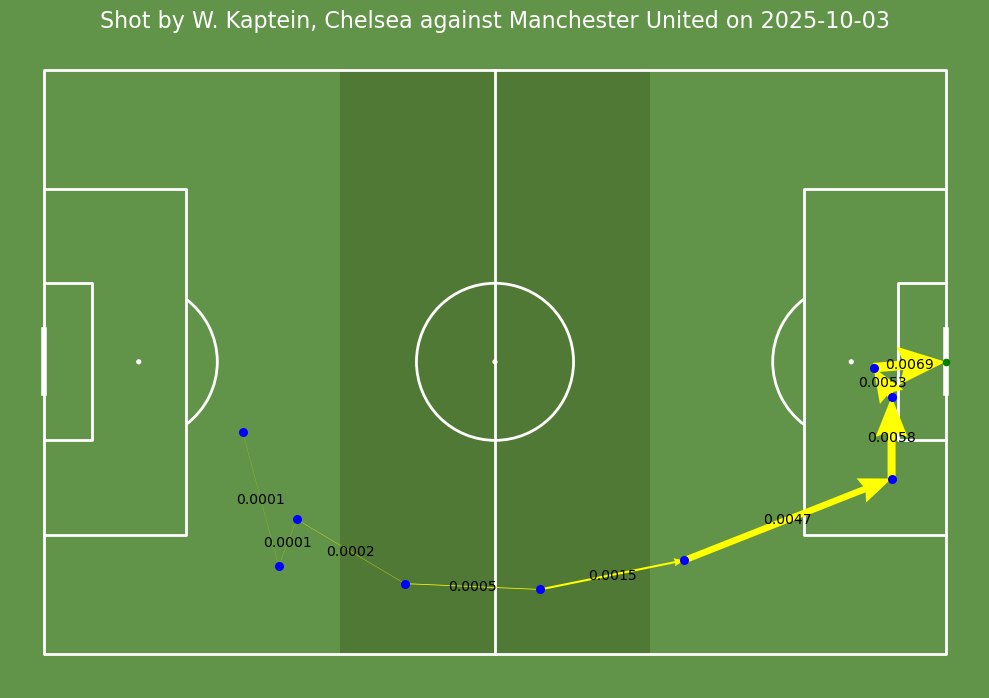

In [65]:
match_id = 5767562
poss_id = 2730504707
possession_rows = abxt_pl.filter(
  (pl.col('matchId') == match_id) &
  (pl.col('possessionId') == poss_id)
)

xt_pitch = Pitch(pitch_type='custom', pitch_length=PITCH_X_M, pitch_width=PITCH_Y_M,
                 pitch_color='#619349', line_color='white', shade_middle=True, shade_color="#507935")
fig, ax = xt_pitch.draw(figsize=(10, 7))

for row in possession_rows.iter_rows(named=True):
  start_x = row['startXMeters']
  start_y = row['startYMeters']
  end_x = row['endXMeters']
  end_y = row['endYMeters']
  xt_pitch.arrows(
    start_x, start_y, end_x, end_y,
    width=(2 * row['actionBasedxT'] * 500),
    headwidth=4, headlength=5, color='yellow', ax=ax
  )
  mid_x = (start_x + end_x) / 2
  mid_y = (start_y + end_y) / 2
  ax.text(
    mid_x,
    mid_y,
    f'{row['actionBasedxT']:.4f}',
    color='black',
    fontsize=10,
    ha='center',
    va='center',
    zorder=4,
  )
  ax.scatter([row['startXMeters']], [row['startYMeters']], color='blue', s=30, zorder=3)
  ax.scatter([row['endXMeters']], [row['endYMeters']], color='green', s=20, zorder=3)

shot_event = possession_rows[-1]
ax.set_title(
  f'Shot by {shot_event[0, "player"]["name"]}, {shot_event[0, "possessionTeamName"]} against {shot_event[0, "opponentTeam"]["name"]} on {shot_event[0, "matchTs"].date()}',
  color='white', fontsize=16
)
fig.patch.set_facecolor('#619349')
plt.show()

## Top players
Find the top players who had the highest xT per 90 minutes in the 2025/2026 season

In [66]:
player_xT_pl = abxt_pl.group_by(
  pl.col('player').struct.field('id').alias('player_id')
).agg(
  pl.col('actionBasedxT').sum()
)

player_mins_pl = minutes_pl.group_by(
  pl.col('player_id')
).agg(
  pl.col('minutes_played').sum()
)

team_names_pl = teams_pl.select(
  pl.col('team_id'),
  pl.col('name').alias('team_name'),
  pl.col('team_abbrv'),
)

player_stats_pl = player_xT_pl.join(player_mins_pl, on='player_id', how='left')
player_stats_pl = player_stats_pl.join(players_pl, on='player_id', how='left')
player_stats_pl = player_stats_pl.join(team_names_pl, on='team_id', how='left')

player_stats_pl = player_stats_pl.with_columns(
  (pl.col('actionBasedxT')*90 / pl.col('minutes_played')).alias('xT_90')
)
player_xD90_pl = player_stats_pl.filter(
  # Only rank players who have more than 400 minutes played
  pl.col('minutes_played') > 400,
  pl.col('role') != 'Goalkeeper',
).sort('xT_90', descending=True).select('player_id', 'short_name', 'team_name', 'team_abbrv', 'actionBasedxT', 'xT_90', 'image_url', 'role')

player_xD90_pl.head(10)

player_id,short_name,team_name,team_abbrv,actionBasedxT,xT_90,image_url,role
i64,str,str,str,f64,f64,str,str
540393,"""L. James""","""Chelsea""","""CHE""",1.56318,0.175858,"""https://cdn5.wyscout.com/photo…","""Forward"""
480979,"""L. Hemp""","""Manchester City""","""MCI""",2.42761,0.157865,"""https://cdn5.wyscout.com/photo…","""Forward"""
478498,"""S. Baltimore""","""Chelsea""","""CHE""",1.984162,0.154209,"""https://cdn5.wyscout.com/photo…","""Forward"""
813153,"""S. Holmberg""","""Arsenal""","""ARS""",0.834596,0.151745,"""https://cdn5.wyscout.com/photo…","""Defender"""
845962,"""A. Thompson""","""Chelsea""","""CHE""",2.063114,0.128766,"""https://cdn5.wyscout.com/photo…","""Forward"""
723231,"""C. Macário""","""Chelsea""","""CHE""",0.686657,0.124595,"""https://cdn5.wyscout.com/photo…","""Midfielder"""
61741,"""C. Foord""","""Arsenal""","""ARS""",1.732241,0.124522,"""https://cdn5.wyscout.com/photo…","""Forward"""
762885,"""S. Gaupset""","""Tottenham Hotspur""","""TOT""",1.277937,0.124474,"""https://cdn5.wyscout.com/photo…","""Midfielder"""
405184,"""C. Holland""","""Liverpool""","""LIV""",2.280349,0.120089,"""https://cdn5.wyscout.com/photo…","""Midfielder"""


## Plot the top players

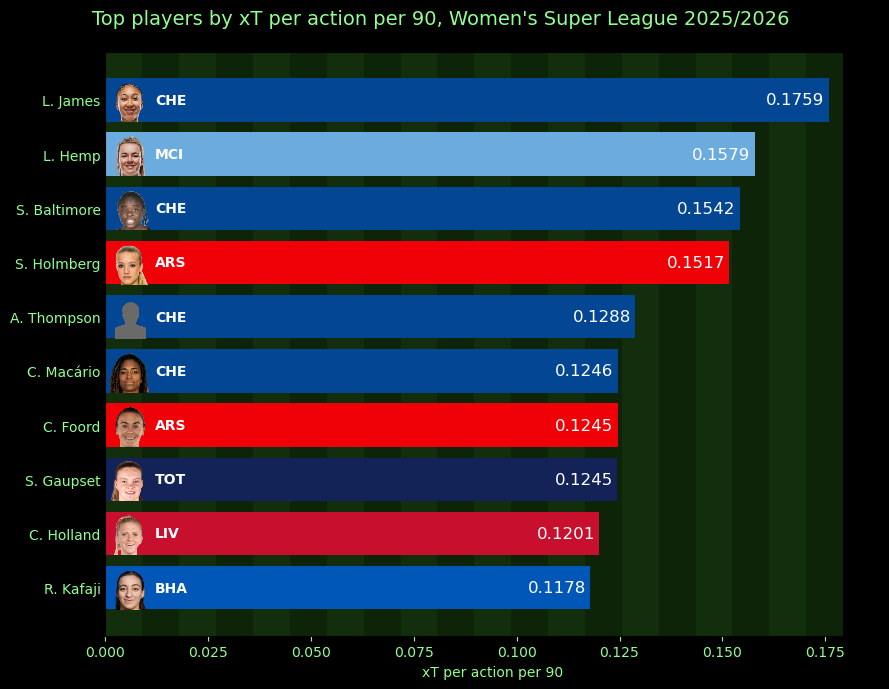

In [67]:

# Sort in reverse order for the bar chart so that the top player is displayed on top
top_players_pd = player_xD90_pl.head(10).sort('xT_90', descending=False).to_pandas().reset_index(drop=True)
# Color each player's bar using their team colors
bar_colors = [wsl_colours[team][0] for team in top_players_pd['team_name'].to_list()]
fig, ax = plt.subplots(figsize=(9, 7))

y = np.arange(len(top_players_pd))
x = top_players_pd['xT_90']
names = top_players_pd['short_name']

ax.set_facecolor('black')
ax.barh(y, x, color=bar_colors, zorder=2)
ax.set_yticks(y)
ax.set_yticklabels(names)
ax.tick_params(axis='y', length=0)
ax.set_xlabel('xT per action per 90')
title = ax.set_title("Top players by xT per action per 90, Women's Super League 2025/2026", fontsize=14, pad=20)
dx = 60 / fig.bbox.width
title.set_position((title.get_position()[0] - dx, title.get_position()[1]))

# Display player headshots
for yi, row in top_players_pd.iterrows():
  image_url = row['image_url']
  resp = requests.get(image_url, timeout=5)
  resp.raise_for_status()
  img = Image.open(BytesIO(resp.content)).convert('RGBA')
  imagebox = OffsetImage(img, zoom=0.22)
  ab = AnnotationBbox(
    imagebox,
    (0.006, yi - 0.04),
    frameon=False,
  )
  ax.add_artist(ab)

  # Team abbreviation label
  ax.text(
    0.012,
    yi,
    row['team_abbrv'],
    ha='left',
    va='center',
    fontsize=10,
    fontweight='bold',
    zorder=3,
    color='white',
  )

# Display the xT value on the bar
for y_val, x_val in zip(y, x):
  ax.text(
    x_val - 0.001,
    y_val,
    f'{x_val:.4f}',
    va='center',
    ha='right',
    fontsize=12,
    color='white')

# Football pitch background
xmax = x.max() * 1.02  # Give a little padding at the end of the longest bar
for i in range(20):
  x0 = xmax * i / 20
  x1 = xmax * (i + 1) / 20
  ax.axvspan(
    x0,
    x1,
    facecolor='#3f9a28' if i % 2 == 0 else '#2e7a1d',
    alpha=0.3,
    zorder=0,
  )

text_color = '#90FF90'
fig.patch.set_facecolor('black')
ax.xaxis.label.set_color(text_color)
ax.yaxis.label.set_color(text_color)
ax.title.set_color(text_color)
ax.tick_params(colors=text_color)

plt.tight_layout()
plt.show()

## Top players by role
Forwards

In [68]:
# Top 10 forwards
player_xD90_pl.filter(
  pl.col('role') == 'Forward'
).sort('xT_90', descending=True).select(
  ['short_name', 'team_name', 'xT_90', 'role']
).head(10)

short_name,team_name,xT_90,role
str,str,f64,str
"""L. James""","""Chelsea""",0.175858,"""Forward"""
"""L. Hemp""","""Manchester City""",0.157865,"""Forward"""
"""S. Baltimore""","""Chelsea""",0.154209,"""Forward"""
"""A. Thompson""","""Chelsea""",0.128766,"""Forward"""
"""C. Foord""","""Arsenal""",0.124522,"""Forward"""
"""R. Kafaji""","""Brighton & Hove Albion""",0.117846,"""Forward"""
"""E. Salmon""","""Aston Villa""",0.117792,"""Forward"""
"""Mariona Caldentey""","""Arsenal""",0.117259,"""Forward"""
"""K. Shaw""","""Manchester City""",0.115225,"""Forward"""


Midfielders

In [69]:
# Top 10 midfielders
player_xD90_pl.filter(
  pl.col('role') == 'Midfielder'
).sort('xT_90', descending=True).select(
  ['short_name', 'team_name', 'xT_90', 'role']
).head(10)

short_name,team_name,xT_90,role
str,str,f64,str
"""C. Macário""","""Chelsea""",0.124595,"""Midfielder"""
"""S. Gaupset""","""Tottenham Hotspur""",0.124474,"""Midfielder"""
"""C. Holland""","""Liverpool""",0.120089,"""Midfielder"""
"""B. Mead""","""Arsenal""",0.111802,"""Midfielder"""
"""E. Toone""","""Manchester United""",0.107411,"""Midfielder"""
"""A. Bergström""","""Liverpool""",0.101661,"""Midfielder"""
"""E. Cuthbert""","""Chelsea""",0.095245,"""Midfielder"""
"""S. Nüsken""","""Chelsea""",0.091575,"""Midfielder"""
"""J. Zigiotti Olme""","""Manchester United""",0.0907,"""Midfielder"""


Defenders

In [70]:
# Top 10 defenders
player_xD90_pl.filter(
  pl.col('role') == 'Defender'
).sort('xT_90', descending=True).select(
  ['short_name', 'team_name', 'xT_90', 'role']
).head(10)

short_name,team_name,xT_90,role
str,str,f64,str
"""S. Holmberg""","""Arsenal""",0.151745,"""Defender"""
"""E. Carpenter""","""Chelsea""",0.115393,"""Defender"""
"""K. McCabe""","""Arsenal""",0.111749,"""Defender"""
"""P. Pattinson""","""London City Lionesses""",0.098135,"""Defender"""
"""A. Sandberg""","""Manchester United""",0.095335,"""Defender"""
"""J. Nighswonger""","""Aston Villa""",0.094318,"""Defender"""
"""F. Rolfö""","""Manchester United""",0.09119,"""Defender"""
"""K. Casparij""","""Manchester City""",0.09034,"""Defender"""
"""E. Fox""","""Arsenal""",0.090031,"""Defender"""


Teams

In [71]:
player_xD90_pl.group_by('team_name').agg(
  pl.col('xT_90').sum().alias('total_player_xD')
).sort('total_player_xD', descending=True).head(10)

team_name,total_player_xD
str,f64
"""Arsenal""",1.709406
"""Chelsea""",1.709005
"""Manchester United""",1.255603
"""Manchester City""",1.253605
"""Aston Villa""",1.099804
"""London City Lionesses""",1.058227
"""Tottenham Hotspur""",1.045329
"""Everton""",1.044963
"""Liverpool""",1.03842


## Players with xD passes
Top players by number of expected dangerous passes

In [72]:
player_xD_passes_pl = abxt_pl.filter(
  pl.col('type').struct.field('primary') == 'pass'
).group_by(
  pl.col('player').struct.field('id').alias('player_id')
).agg(
  pl.len().alias('num_xD_passes')
)

player_pass_stats_pl = player_xD_passes_pl.join(player_mins_pl, on='player_id', how='left')
player_pass_stats_pl = player_pass_stats_pl.join(players_pl, on='player_id', how='left')
player_pass_stats_pl = player_pass_stats_pl.join(team_names_pl, on='team_id', how='left')

# Get the top players by expected danger
player_xD_passes_pl = player_pass_stats_pl.filter(
  # Only rank players who have more than 400 minutes played
  pl.col('minutes_played') > 400,
  pl.col('role') != 'Goalkeeper',
).sort('num_xD_passes', descending=True).select('player_id', 'short_name', 'team_name', 'team_abbrv', 'num_xD_passes', 'image_url', 'role')

player_xD_passes_pl.head(10)

player_id,short_name,team_name,team_abbrv,num_xD_passes,image_url,role
i64,str,str,str,u32,str,str
559233,"""M. Le Tissier""","""Manchester United""","""MUN""",1161,"""https://cdn5.wyscout.com/photo…","""Defender"""
230995,"""Mariona Caldentey""","""Arsenal""","""ARS""",975,"""https://cdn5.wyscout.com/photo…","""Forward"""
592329,"""J. Rose""","""Manchester City""","""MCI""",840,"""https://cdn5.wyscout.com/photo…","""Defender"""
496941,"""J. Clark""","""Liverpool""","""LIV""",838,"""https://cdn5.wyscout.com/photo…","""Defender"""
302839,"""M. Minami""","""Brighton & Hove Albion""","""BHA""",781,"""https://cdn5.wyscout.com/photo…","""Defender"""
353246,"""G. Fisk""","""Liverpool""","""LIV""",776,"""https://cdn5.wyscout.com/photo…","""Defender"""
134119,"""D. Janssen""","""Manchester United""","""MUN""",775,"""https://cdn5.wyscout.com/photo…","""Defender"""
655808,"""R. Mace""","""Everton""","""EVE""",757,"""https://cdn5.wyscout.com/photo…","""Midfielder"""
808627,"""Martina Fernández""","""Everton""","""EVE""",748,"""https://cdn5.wyscout.com/photo…","""Defender"""


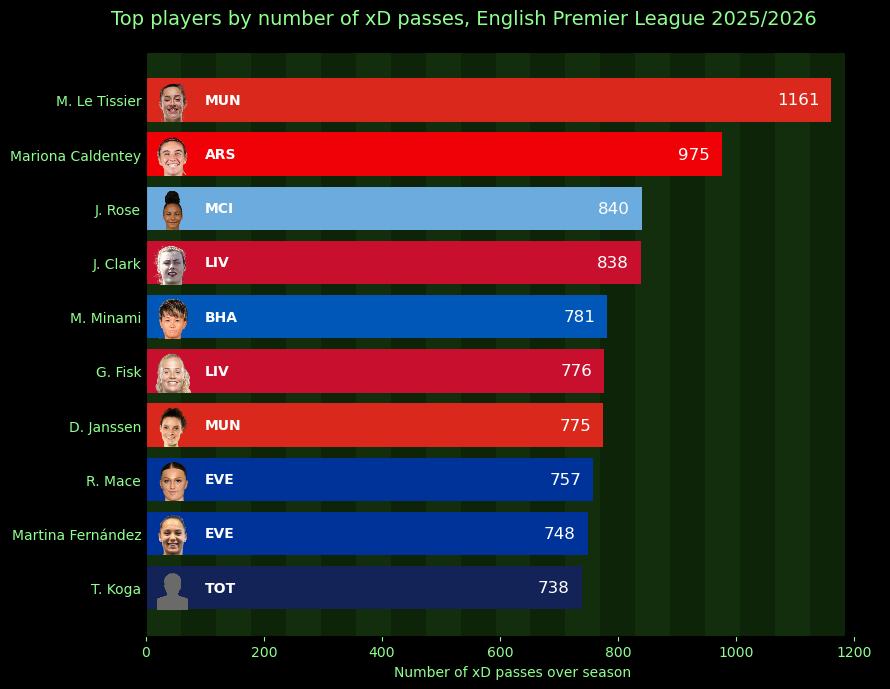

In [73]:
# Sort in reverse order for the bar chart so that the top player is displayed on top
top_players_pd = player_xD_passes_pl.head(10).sort('num_xD_passes', descending=False).to_pandas().reset_index(drop=True)
# Color each player's bar using their team colors
bar_colors = [wsl_colours[team][0] for team in top_players_pd['team_name'].to_list()]
fig, ax = plt.subplots(figsize=(9, 7))

y = np.arange(len(top_players_pd))
x = top_players_pd['num_xD_passes']
names = top_players_pd['short_name']

ax.set_facecolor('black')
ax.barh(y, x, color=bar_colors, zorder=2)
ax.set_yticks(y)
ax.set_yticklabels(names)
ax.tick_params(axis='y', length=0)
ax.set_xlabel('Number of xD passes over season')
title = ax.set_title('Top players by number of xD passes, English Premier League 2025/2026', fontsize=14, pad=20)
dx = 60 / fig.bbox.width
title.set_position((title.get_position()[0] - dx, title.get_position()[1]))

chart_text_colors = []

# Display player headshots
for yi, row in top_players_pd.iterrows():
  image_url = row['image_url']
  resp = requests.get(image_url, timeout=5)
  resp.raise_for_status()
  img = Image.open(BytesIO(resp.content)).convert('RGBA')
  imagebox = OffsetImage(img, zoom=0.22)
  ab = AnnotationBbox(
    imagebox,
    (45, yi - 0.04),
    frameon=False,
  )
  ax.add_artist(ab)

  # Have to account for Fulham's primary color being white
  text_color = ('black' if row['team_abbrv'] == 'FUL' else 'white')
  chart_text_colors.append(text_color)
  
  # Team abbreviation label
  ax.text(
    100,
    yi,
    row['team_abbrv'],
    ha='left',
    va='center',
    fontsize=10,
    fontweight='bold',
    zorder=3,
    color=text_color
  )

# Display number of passes value on the bar
for i, (y_val, x_val) in enumerate(zip(y, x)):
  ax.text(
    x_val - 20,
    y_val,
    f'{x_val}',
    va='center',
    ha='right',
    fontsize=12,
    color=chart_text_colors[i],
)

# Football pitch background
xmax = x.max() * 1.02  # Give a little padding at the end of the longest bar
for i in range(20):
  x0 = xmax * i / 20
  x1 = xmax * (i + 1) / 20
  ax.axvspan(
    x0,
    x1,
    facecolor='#3f9a28' if i % 2 == 0 else '#2e7a1d',
    alpha=0.3,
    zorder=0,
  )

text_color = '#90FF90'
fig.patch.set_facecolor('black')
ax.xaxis.label.set_color(text_color)
ax.yaxis.label.set_color(text_color)
ax.title.set_color(text_color)
ax.tick_params(colors=text_color)

plt.tight_layout()
plt.show()